In [1]:
import os
import cv2
import numpy as np


import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:

dataset_path = 'Banana-Ripeness-Classification-Dataset/train'  

kategori = ['unripe', 'ripe', 'overripe', 'rotten']

X_train_asli = []
y_train_asli = []

print("Memulai ekstraksi fitur (Mean HSV) dari dataset latih...")

for label in kategori:
    folder_path = os.path.join(dataset_path, label)
    
    if not os.path.exists(folder_path):
        print(f"Peringatan: Folder '{label}' tidak ditemukan di '{dataset_path}'!")
        continue
        
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img_bgr = cv2.imread(img_path)
        
        if img_bgr is None:
            continue 
            
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (128, 128))
        
        img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_RGB2HSV)
        H, S, V = cv2.split(img_hsv)
        
        mean_hsv = [round(np.mean(H), 2), round(np.mean(S), 2), round(np.mean(V), 2)]
        
        X_train_asli.append(mean_hsv)
        y_train_asli.append(label)

X_train = np.array(X_train_asli)
y_train = np.array(y_train_asli)

print(f"Selesai! Berhasil mengekstrak fitur dari {len(X_train)} gambar latih.")

Memulai ekstraksi fitur (Mean HSV) dari dataset latih...
Selesai! Berhasil mengekstrak fitur dari 11793 gambar latih.


In [ ]:
import random

def tampilkan_tabel_per_kategori(X_train, y_train, kategori_list, jumlah=15):
    headers = ['No', 'Index', 'Mean H', 'Mean S', 'Mean V']

    for cat in kategori_list:
        idxs = np.where(y_train == cat)[0]

        if len(idxs) == 0:
            print(f"\nKategori {cat} tidak memiliki data.\n")
            continue

        sample_size = min(jumlah, len(idxs))
        sampled_idxs = random.sample(list(idxs), sample_size)

        print("\n" + "="*60)
        print(f"TABEL KATEGORI: {cat.upper()} ({sample_size} data)")
        print("="*60)

       
        print("{:<5} {:<8} {:<10} {:<10} {:<10}".format(*headers))
        print("-"*60)

    
        for i, idx in enumerate(sampled_idxs, start=1):
            h, s, v = X_train[idx]
            print("{:<5} {:<8} {:<10} {:<10} {:<10}".format(
                i,
                idx,
                round(h, 2),
                round(s, 2),
                round(v, 2)
            ))

tampilkan_tabel_per_kategori(X_train, y_train, kategori, jumlah=15)


TABEL KATEGORI: UNRIPE (15 data)
No    Index    Mean H     Mean S     Mean V    
------------------------------------------------------------
1     1628     95.7       49.48      202.41    
2     1013     78.61      45.76      177.43    
3     789      74.5       63.7       149.97    
4     499      57.24      119.45     147.16    
5     601      45.84      40.57      121.14    
6     537      52.6       62.02      143.92    
7     34       75.65      55.98      166.21    
8     1430     61.05      52.15      143.06    
9     1065     95.06      46.46      201.12    
10    501      81.49      51.24      186.97    
11    809      81.35      72.05      171.66    
12    597      51.27      95.61      177.46    
13    1233     45.26      59.88      99.32     
14    1053     89.59      68.42      168.44    
15    668      45.14      57.79      149.82    

TABEL KATEGORI: RIPE (15 data)
No    Index    Mean H     Mean S     Mean V    
---------------------------------------------------------

3 Gambar terpilih: ['musa-acuminata-overripe-800695c4-2653-11ec-a5c4-d8c4975e38aa_jpg.rf.84b9385c9eda54b529c16461dae74726.jpg', 'musa-acuminata-overripe-800b04df-2653-11ec-a4b2-d8c4975e38aa_jpg.rf.b9ffa69fc845766680d69306d78bc598.jpg', 'musa-acuminata-overripe-9cc2796e-1d0a-11ec-9270-d8c4975e38aa_jpg.rf.916607117bd1c8dbfcd0858fac034b97.jpg']

=== HASIL GAMBAR 1: musa-acuminata-overripe-800695c4-2653-11ec-a5c4-d8c4975e38aa_jpg.rf.84b9385c9eda54b529c16461dae74726.jpg ===
Mean HSV: [np.float64(84.08), np.float64(33.4), np.float64(160.66)]

=== HASIL GAMBAR 2: musa-acuminata-overripe-800b04df-2653-11ec-a4b2-d8c4975e38aa_jpg.rf.b9ffa69fc845766680d69306d78bc598.jpg ===
Mean HSV: [np.float64(84.5), np.float64(37.15), np.float64(150.84)]

=== HASIL GAMBAR 3: musa-acuminata-overripe-9cc2796e-1d0a-11ec-9270-d8c4975e38aa_jpg.rf.916607117bd1c8dbfcd0858fac034b97.jpg ===
Mean HSV: [np.float64(88.06), np.float64(54.51), np.float64(184.22)]


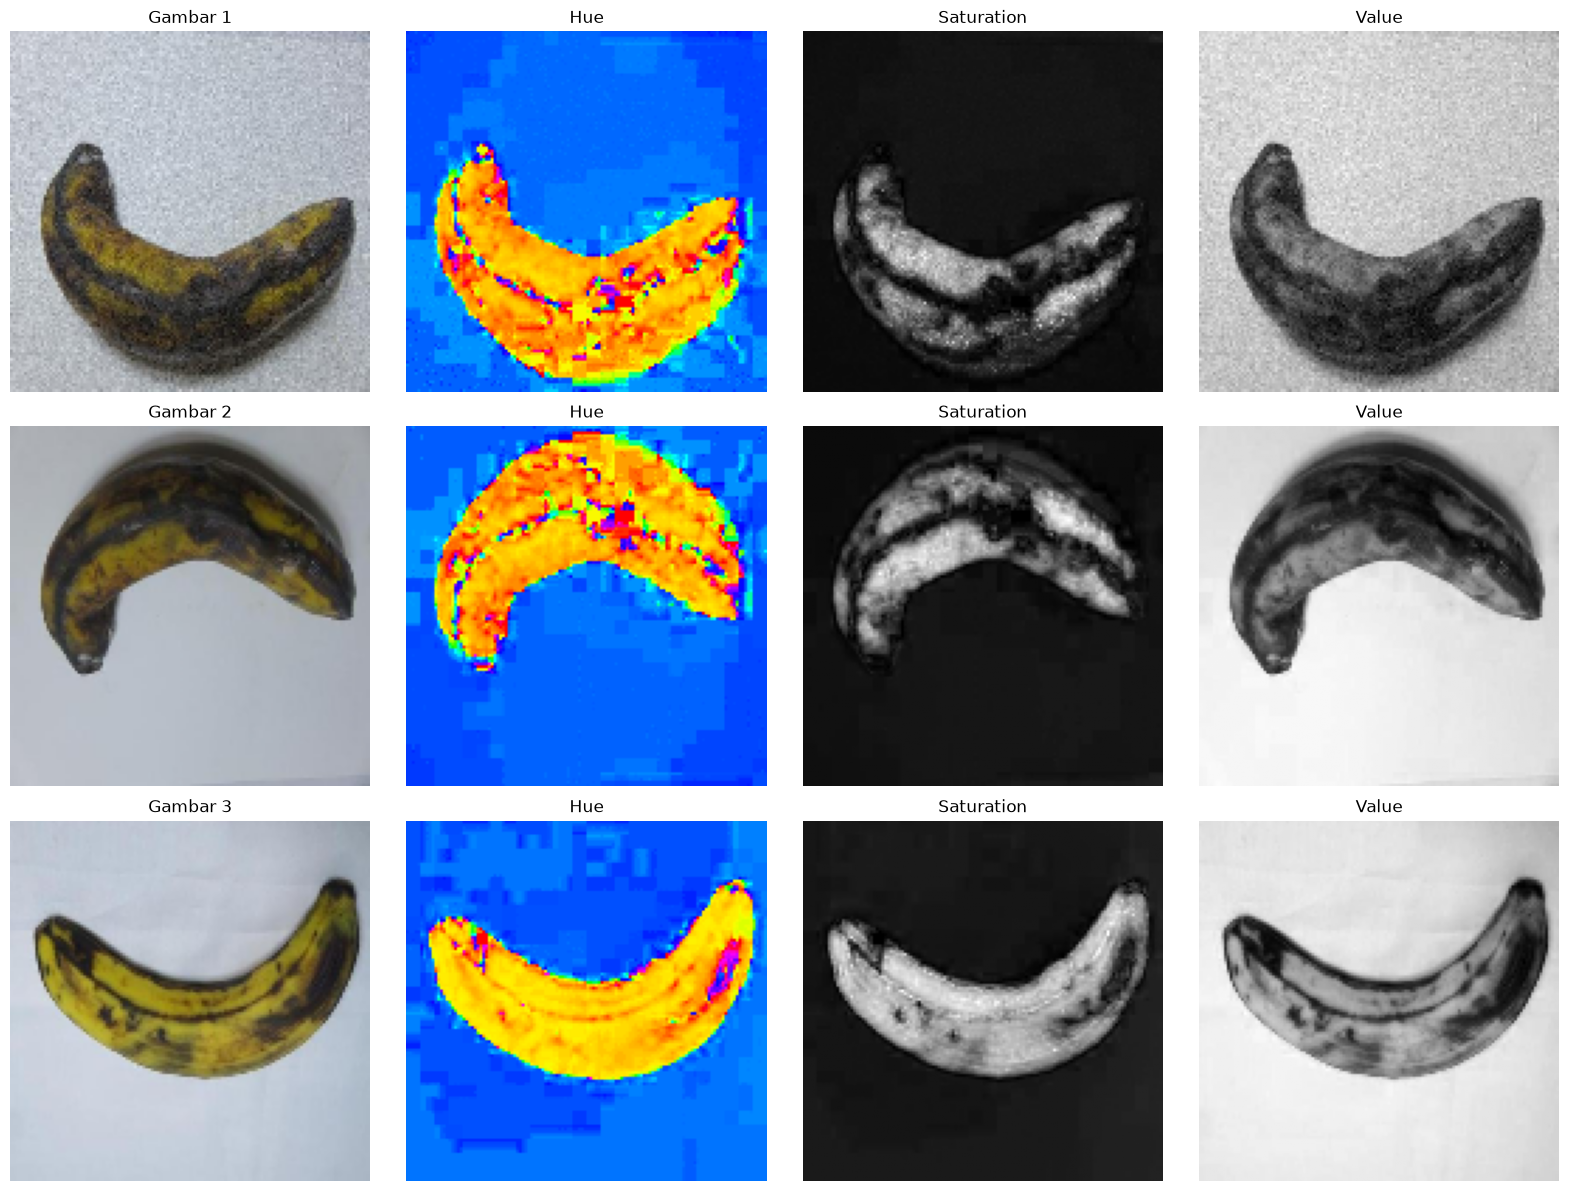


=== DATA UJI FINAL ===
[[ 84.08  33.4  160.66]
 [ 84.5   37.15 150.84]
 [ 88.06  54.51 184.22]]
Shape: (3, 3)


In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

folder_path = 'Banana-Ripeness-Classification-Dataset/test/overripe'

files = os.listdir(folder_path)
image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(image_files) == 0:
    print("Tidak ada gambar dalam folder!")
else:
    sample_size = min(3, len(image_files))
    random_images = random.sample(image_files, sample_size)

    print(f"3 Gambar terpilih: {random_images}")

    fig, axes = plt.subplots(sample_size, 4, figsize=(16, 4 * sample_size))

    all_test_features = []

    for i, img_name in enumerate(random_images):
        image_path = os.path.join(folder_path, img_name)
        img_bgr = cv2.imread(image_path)

        if img_bgr is None:
            print(f"Error membaca {img_name}")
            continue

        # PREPROCESSING
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (128, 128))

        img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_RGB2HSV)
        H, S, V = cv2.split(img_hsv)

        mean_h = np.mean(H)
        mean_s = np.mean(S)
        mean_v = np.mean(V)

        test_features = [round(mean_h, 2), round(mean_s, 2), round(mean_v, 2)]

        all_test_features.append(test_features)

        
        print(f"\n=== HASIL GAMBAR {i+1}: {img_name} ===")
        print(f"Mean HSV: {test_features}")

        
        ax = axes[i] if sample_size > 1 else axes

        ax[0].imshow(img_resized)
        ax[0].set_title(f"Gambar {i+1}")
        ax[0].axis('off')

        ax[1].imshow(H, cmap='hsv')
        ax[1].set_title('Hue')
        ax[1].axis('off')

        ax[2].imshow(S, cmap='gray')
        ax[2].set_title('Saturation')
        ax[2].axis('off')

        ax[3].imshow(V, cmap='gray')
        ax[3].set_title('Value')
        ax[3].axis('off')

    plt.tight_layout()
    plt.show()

    test_data = np.array(all_test_features)

    print("\n=== DATA UJI FINAL ===")
    print(test_data)
    print("Shape:", test_data.shape)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np


if 'test_data' in locals():
    
    k_value = 3
    
    
    knn = KNeighborsClassifier(n_neighbors=k_value, metric='euclidean')
    knn.fit(X_train, y_train)
    
    
    prediksi = knn.predict(test_data)
    jarak, indeks = knn.kneighbors(test_data)
    
    print("\n=== HASIL KLASIFIKASI K-NEAREST NEIGHBOR ===")
    print(f"Nilai K yang digunakan : {k_value}")
    
   
    for i in range(len(test_data)):
        print("\n" + "="*60)
        print(f"DATA UJI KE-{i+1}")
        print("="*60)
        
        print(f"Fitur HSV         : {test_data[i]}")
        print(f"Prediksi Kelas    : {prediksi[i].upper()}")
        
        print("\n--- 3 Tetangga Terdekat ---")
        for j in range(k_value):
            idx = indeks[i][j]
            label_tetangga = y_train[idx]
            fitur_tetangga = X_train[idx]
            jarak_tetangga = round(jarak[i][j], 2)
            
            print(f"{j+1}. Kelas: {label_tetangga.upper()} | "
                  f"Jarak: {jarak_tetangga} | "
                  f"HSV: {fitur_tetangga}")
else:
    print("Data uji belum tersedia!")


=== HASIL KLASIFIKASI K-NEAREST NEIGHBOR ===
Nilai K yang digunakan : 3

DATA UJI KE-1
Fitur HSV         : [ 84.08  33.4  160.66]
Prediksi Kelas    : OVERRIPE

--- 3 Tetangga Terdekat ---
1. Kelas: ROTTEN | Jarak: 2.4 | HSV: [ 81.8   33.29 161.41]
2. Kelas: OVERRIPE | Jarak: 2.84 | HSV: [ 84.2   30.73 159.7 ]
3. Kelas: OVERRIPE | Jarak: 3.29 | HSV: [ 86.1   33.28 163.25]

DATA UJI KE-2
Fitur HSV         : [ 84.5   37.15 150.84]
Prediksi Kelas    : OVERRIPE

--- 3 Tetangga Terdekat ---
1. Kelas: OVERRIPE | Jarak: 1.74 | HSV: [ 85.33  36.82 152.33]
2. Kelas: OVERRIPE | Jarak: 1.78 | HSV: [ 85.69  35.86 150.52]
3. Kelas: OVERRIPE | Jarak: 2.28 | HSV: [ 84.13  38.01 148.76]

DATA UJI KE-3
Fitur HSV         : [ 88.06  54.51 184.22]
Prediksi Kelas    : OVERRIPE

--- 3 Tetangga Terdekat ---
1. Kelas: OVERRIPE | Jarak: 0.24 | HSV: [ 87.84  54.49 184.12]
2. Kelas: OVERRIPE | Jarak: 0.69 | HSV: [ 88.04  53.96 184.64]
3. Kelas: OVERRIPE | Jarak: 0.76 | HSV: [ 88.38  54.09 184.76]
